In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('dataset/messy_customer_sales_data.csv')
df

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
0,CUST4371,Paul Wilson,m,52.0,KOLKATA,2025-06-26,2025-05-17,26944.0,1.0,peckvictoria@example.com,2131107701,India
1,CUST5957,Jason Thomas,M,51.0 years,NaN,2021-02-17,2025-07-22,44152.0,2.0,owensanthony@example.com,1080761560,india
2,CUST3754,Brittney Martinez,F,62.0,hyderabad,2023-11-05,2024-12-08,31745.0,2.0,tara39@example.org,8981006345,India
3,CUST2934,Brenda Pierce,FEMALE,40.0,hyderabad,2022-03-13,2025-10-02,39674.0,1.0,berrynancy@example.org,8228064204,india
4,CUST5683,Matthew Carroll,f,41.0,CHENNAI,2024-04-05,2024-12-15,NaN,8.0,denise84@example.org,2665569480,India
...,...,...,...,...,...,...,...,...,...,...,...,...
10195,CUST10767,Robert Lewis,female,35.0 years,delhi,2020-12-08,2025-01-25,24167.0,9.0,barrycrane@example.net,5004696571,InDia
10196,NaN,Diane Evans,M,53.0,bangalore,2023-12-31,2025-05-07,11639.0,7.0,lisadennis@example.net,5200349941,IND
10197,CUST6315,Joshua Martinez,m,25.0,hyderabad,2022-02-15,2025-01-11,43832.0,2.0,kelli74@example.org,8147428496,India
10198,CUST4812,Sarah Miller,FEMALE,55.0,NaN,2021-03-16,2025-05-14,18827.0,10.0,dawn84@example.org,2987564247,InDia


In [3]:
# If you want the report to be open directly in the browser — uncomment 
# the lines

# import webbrowser
# import os

# from ydata_profiling import ProfileReport
# profile = ProfileReport(df, title="Profile Report", explorative=True)
# profile.to_file("report.html")

# webbrowser.open("file://" + os.path.abspath("report.html"))

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         9177 non-null   object 
 1   Name                10200 non-null  object 
 2   Gender              9174 non-null   object 
 3   Age                 9249 non-null   object 
 4   City                9184 non-null   object 
 5   Signup_Date         10200 non-null  object 
 6   Last_Purchase_Date  9188 non-null   object 
 7   Purchase_Amount     9179 non-null   float64
 8   Feedback_Score      9177 non-null   float64
 9   Email               10200 non-null  object 
 10  Phone_Number        10200 non-null  int64  
 11  Country             9468 non-null   object 
dtypes: float64(2), int64(1), object(9)
memory usage: 956.4+ KB


**Summary Statistics**

In [5]:
df.describe().round()

,Purchase_Amount,Feedback_Score,Phone_Number
count,9179.0,9177.0,1.020000e+04
mean,29090.0,5.0,4.979974e+09
std,208697.0,3.0,2.902593e+09
min,-500.0,1.0,9.208990e+05
25%,12295.0,3.0,2.449157e+09
50%,24330.0,5.0,4.988639e+09
75%,37130.0,8.0,7.510448e+09
max,9999999.0,10.0,9.994402e+09


In [6]:
df.isnull().sum()

Customer_ID           1023
Name                     0
Gender                1026
Age                    951
City                  1016
Signup_Date              0
Last_Purchase_Date    1012
Purchase_Amount       1021
Feedback_Score        1023
Email                    0
Phone_Number             0
Country                732
dtype: int64

In [7]:
df.isnull().sum() / len(df) * 100 # To see the missing value percentage

Customer_ID           10.029412
Name                   0.000000
Gender                10.058824
Age                    9.323529
City                   9.960784
Signup_Date            0.000000
Last_Purchase_Date     9.921569
Purchase_Amount       10.009804
Feedback_Score        10.029412
Email                  0.000000
Phone_Number           0.000000
Country                7.176471
dtype: float64

If we encounter missing values, we can't just apply drop function mindlessly.

In [8]:
df.shape

(10200, 12)

In [9]:
df.dropna().shape

(4528, 12)

More than 60% of the data will be lost if we just use drop.

In [10]:
df[df.duplicated()].shape

(15, 12)

In [11]:
df[df.duplicated()]

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
2032,CUST2755,Casey Campbell,male,NaN,Hyderabad,2023-12-01,2024-11-04,11778.0,3.0,joseph49@example.com,3844741384,India
3191,NaN,Travis Schneider,f,51.0,NaN,2025-04-20,2025-02-28,48750.0,5.0,bianca77@example.net,7623118785,India
4312,CUST8305,Stanley Cain,FEMALE,51.0,Bangalore,2023-08-14,2024-11-01,11432.0,6.0,calderonbrenda@example.org,4889366037,India
5611,CUST6288,Jonathon Kim,male,46.0,Chennai,2023-11-22,2025-03-21,3301.0,6.0,tparker@example.com,5266662560,India
5680,CUST2695,Lisa Durham,NaN,46.0,Chennai,2021-04-18,2024-10-10,6511.0,3.0,andrew34@example.com,2235480149,India
5899,CUST8841,Amanda Hill,NaN,34.0,chennai,2022-09-11,2025-03-13,42092.0,4.0,ryanriley@example.net,3466026146,India
6070,CUST10780,Emily Smith,NaN,23.0,Kolkata,2023-12-09,2024-10-28,18027.0,5.0,perezchristopher@example.com,3032282870,India
6240,CUST9745,David Morales,NaN,56.0,NaN,2023-02-18,2024-12-14,49107.0,7.0,juliaknapp@example.com,9436163110,India
6425,CUST4631,George Villa,m,26.0,Mumbai,2022-05-21,2025-06-17,NaN,8.0,davidmarquez@example.com,8869465862,India
6498,CUST1711,Stephanie Elliott,NaN,44.0,MUMBAI,2023-05-17,2025-07-12,11349.0,9.0,nfischer@example.com,3270872546,NaN


We can directly remove duplicate cells

In [12]:
df['Customer_ID'].value_counts()

Customer_ID
CUST3344     2
CUST4893     2
CUST7000     2
CUST10824    2
CUST2695     2
            ..
CUST7857     1
CUST3881     1
CUST1565     1
CUST9038     1
CUST5957     1
Name: count, Length: 9000, dtype: int64

AS it's the PK, there shouldn't be more than one records. Let's inspect what's wrong 

In [13]:
df[df['Customer_ID'] == 'CUST3344']

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
4483,CUST3344,John Russell,M,65.0,MUMBAI,2023-11-21,2025-08-10,36235.0,8.0,sandra86@example.org,4225788150,India
6218,CUST3344,John Russell,male,65.0,Mumbai,2023-11-21,2025-08-10,36235.0,8.0,sandra86@example.org,4225788150,India


Gender and City col is showing same data in different format that's why we're seeing duplicate records. We can completely remove them. 

Let's see what unique values are present in our categorical data

In [14]:
for col in df.columns:
    if df[col].nunique() < 20:
        print(df[col].value_counts())
        print('-'*50)
        

Gender
f         1184
M         1171
m         1163
F         1157
MALE      1131
female    1128
male      1121
FEMALE    1119
Name: count, dtype: int64
--------------------------------------------------
City
Kolkata       820
Mumbai        812
Chennai       784
Bangalore     773
Hyderabad     770
Delhi         763
CHENNAI       404
KOLKATA       395
MUMBAI        393
hyderabad     384
bangalore     383
DELHI         378
delhi         369
BANGALORE     363
HYDERABAD     360
mumbai        352
chennai       343
kolkata       338
Name: count, dtype: int64
--------------------------------------------------
Feedback_Score
2.0     952
4.0     947
7.0     938
6.0     927
3.0     913
8.0     912
1.0     907
9.0     903
10.0    901
5.0     877
Name: count, dtype: int64
--------------------------------------------------
Country
India    7132
IND       793
india     772
InDia     771
Name: count, dtype: int64
--------------------------------------------------


**Handling missing data**

In [15]:
df.dropna(subset=['Customer_ID'], inplace=True) # dropna always removes missing values. Subset tells a specific column to remove from
df

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
0,CUST4371,Paul Wilson,m,52.0,KOLKATA,2025-06-26,2025-05-17,26944.0,1.0,peckvictoria@example.com,2131107701,India
1,CUST5957,Jason Thomas,M,51.0 years,NaN,2021-02-17,2025-07-22,44152.0,2.0,owensanthony@example.com,1080761560,india
2,CUST3754,Brittney Martinez,F,62.0,hyderabad,2023-11-05,2024-12-08,31745.0,2.0,tara39@example.org,8981006345,India
3,CUST2934,Brenda Pierce,FEMALE,40.0,hyderabad,2022-03-13,2025-10-02,39674.0,1.0,berrynancy@example.org,8228064204,india
4,CUST5683,Matthew Carroll,f,41.0,CHENNAI,2024-04-05,2024-12-15,NaN,8.0,denise84@example.org,2665569480,India
...,...,...,...,...,...,...,...,...,...,...,...,...
10194,CUST6146,Cody Thompson,f,40.0,NaN,2024-08-21,2024-10-26,35101.0,1.0,mitchellrivera@example.net,6380823112,India
10195,CUST10767,Robert Lewis,female,35.0 years,delhi,2020-12-08,2025-01-25,24167.0,9.0,barrycrane@example.net,5004696571,InDia
10197,CUST6315,Joshua Martinez,m,25.0,hyderabad,2022-02-15,2025-01-11,43832.0,2.0,kelli74@example.org,8147428496,India
10198,CUST4812,Sarah Miller,FEMALE,55.0,NaN,2021-03-16,2025-05-14,18827.0,10.0,dawn84@example.org,2987564247,InDia


Duplicate values in Customer_ID is still not removed 

In [16]:
df['Customer_ID'].duplicated().sum()

np.int64(177)

Now that missing records are gone, we need to perform imputations to the rest of the cols with missing values.

In [17]:
df['Age'].unique()

array(['52.0', '51.0 years', '62.0', '40.0', '41.0', nan, '18.0',
       '43.0 years', '40.0 years', '26.0', '32.0', '22.0', '59.0', '65.0',
       '61.0', '31.0', '54.0 years', '55.0', '69.0', '61.0 years', '24.0',
       '63.0', '19.0', '50.0', '56.0', '36.0', '68.0', '43.0', '38.0',
       '27.0', '57.0 years', '23.0', '25.0', '66.0', '28.0', '30.0',
       '46.0', '48.0', '20.0', '37.0', '67.0', '51.0', '35.0', '58.0',
       '29.0', 'nan years', '39.0', '49.0', '47.0', '42.0', '44.0',
       '64.0', '53.0', '60.0', '59.0 years', '45.0', '21.0', '34.0',
       '54.0', '48.0 years', '46.0 years', '33.0', '57.0', '30.0 years',
       '58.0 years', '35.0 years', '34.0 years', '69.0 years', '250',
       '19.0 years', '27.0 years', '53.0 years', '65.0 years',
       '66.0 years', '44.0 years', '49.0 years', '25.0 years',
       '23.0 years', '62.0 years', '41.0 years', '33.0 years',
       '28.0 years', '22.0 years', '20.0 years', '42.0 years',
       '45.0 years', '3', '63.0 years', '

We can see there are some outliers and nan values. In order to remove them we have to extract the numbers first 

In [18]:
import re
# df['Age'].apply(lambda x: re.findall('[0-9]+', str(x)))

def extract_age(age):
    age_num = re.findall('[0-9]+', str(age))
    if len(age_num) > 0:
        return age_num[0]
    else:
        return age

df['Age'] = df['Age'].apply(lambda x: extract_age(x))


In [19]:
df['Age'].unique()

array(['52', '51', '62', '40', '41', nan, '18', '43', '26', '32', '22',
       '59', '65', '61', '31', '54', '55', '69', '24', '63', '19', '50',
       '56', '36', '68', '38', '27', '57', '23', '25', '66', '28', '30',
       '46', '48', '20', '37', '67', '35', '58', '29', 'nan years', '39',
       '49', '47', '42', '44', '64', '53', '60', '45', '21', '34', '33',
       '250', '3', '10'], dtype=object)

In [20]:
df['Age'].isna().sum()

np.int64(859)

So there is 859 missing values 

In [21]:
df['Age'].value_counts(dropna=False)

Age
NaN          859
66           187
62           183
43           182
38           179
34           177
40           176
49           174
54           174
30           172
52           171
53           169
45           168
46           168
19           168
64           166
29           165
42           165
25           163
41           163
61           163
21           162
35           162
68           160
32           160
39           160
51           160
22           158
57           158
28           157
56           156
37           155
20           155
59           155
69           154
27           154
23           154
55           153
47           152
18           152
31           152
33           147
36           147
63           145
50           144
67           144
26           143
58           140
65           140
24           137
60           134
44           132
48           131
nan years     57
250            7
3              5
10             3
Name: count, dtype: int64

In [22]:
# df2 = df.assign(Age=df['Age'].str.replace('years', '').str.strip())
# df2['Age'].unique()
# Does the exact same thing as above. First removes years and strips away any trailing space


We still can't find the median because the data type is object.
Let's start by removing

In [23]:
df2 = df.assign(Age = df['Age'].str.replace('nan years', '').str.strip())

In [24]:
df2['Age'].value_counts(dropna=False)

Age
NaN    859
66     187
62     183
43     182
38     179
34     177
40     176
49     174
54     174
30     172
52     171
53     169
45     168
46     168
19     168
64     166
29     165
42     165
25     163
41     163
61     163
21     162
35     162
68     160
32     160
39     160
51     160
22     158
57     158
28     157
56     156
37     155
20     155
59     155
69     154
27     154
23     154
55     153
47     152
18     152
31     152
33     147
36     147
63     145
50     144
67     144
26     143
58     140
65     140
24     137
60     134
44     132
48     131
        57
250      7
3        5
10       3
Name: count, dtype: int64

In [25]:
df2['Age'].unique()

array(['52', '51', '62', '40', '41', nan, '18', '43', '26', '32', '22',
       '59', '65', '61', '31', '54', '55', '69', '24', '63', '19', '50',
       '56', '36', '68', '38', '27', '57', '23', '25', '66', '28', '30',
       '46', '48', '20', '37', '67', '35', '58', '29', '', '39', '49',
       '47', '42', '44', '64', '53', '60', '45', '21', '34', '33', '250',
       '3', '10'], dtype=object)

We only have empty strings and missing values left.

In [26]:
df2['Age'] = df2['Age'].replace('', pd.NA) # pd.NA will replace empty strings with <NA> 

If we use dropna then it will get rid off all the missing values so there won't be any values to impute with median 

In [27]:
df2['Age'].isna().sum()

np.int64(916)

All the empty strings from Age is gone now. 

Let's now change the dtype to int, but we can't do that directly — the column is still string type ('52', '51', ...) and also has missing values, and int64 can hold neither strings nor NaN. So first we convert to numeric (float) using pd.to_numeric, which turns the string digits into actual numbers and also unifies our missing markers into proper NaN. float64 can hold NaN, so this step works cleanly. Then median can be computed — it ignores NaN by default. Finally, once we fillna() the median in, there are no NaNs left, so we can safely cast to int64.

In [28]:
df2['Age'] = pd.to_numeric(df2['Age'])

In [29]:
median_age = df2['Age'].median()
df2['Age'] = df2['Age'].fillna(median_age)
df2['Age'] = df2['Age'].astype('int64')
df = df2
df['Age'].count()


np.int64(9177)

Purchase Amount is Float and only has missing values so we can directly replace them.

In [30]:
df['Purchase_Amount'].fillna(df['Purchase_Amount'].median(), inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_13380\1054919853.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Purchase_Amount'].fillna(df['Purchase_Amount'].median(), inplace=True)


Even though Feedback Score is numerical, it's discrete categorical value so we use Mode to impute this column.

In [31]:
# df['Feedback_Score'].fillna(df['Feedback_Score'].mode()[0], inplace = True)
# This one is going to get depcricated in future. So better to be suited in this
df.fillna({'Feedback_Score' : df['Feedback_Score'].mode()[0]}, inplace=True)

In [32]:
df['Feedback_Score'].isna().sum()

np.int64(0)

**Filling missing categorical values with the mode**

For `Gender`, `City`, and `Country`, we fill missing values with each column's most 
frequent value (the mode).

Note: `df[col].mode()` returns a **Series**, not a plain scalar — a column could 
technically have more than one mode (a tie), so pandas always returns it as a Series 
even when there's only one result. If we pass that Series straight into `fillna()`, 
pandas tries to align it by index instead of broadcasting it to every missing row, 
so the fill silently fails to work as expected (no error, just wrong/incomplete results).

Using `.mode()[0]` pulls out the actual scalar value at position 0, so `fillna()` 
applies it uniformly to every NaN in the column — no index alignment involved.

In [33]:
df.isnull().sum()

Customer_ID             0
Name                    0
Gender                934
Age                     0
City                  918
Signup_Date             0
Last_Purchase_Date    914
Purchase_Amount         0
Feedback_Score          0
Email                   0
Phone_Number            0
Country               664
dtype: int64

Now instead of performing the same operation in Gender, City and Country we can do this using a loop.

In [34]:
for col in ('Gender', 'City', 'Country'):
    df.fillna({col : df[col].mode()[0]}, inplace = True)

In [35]:
df['Last_Purchase_Date'].ffill(inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_13380\3085584411.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Last_Purchase_Date'].ffill(inplace=True)


In [36]:
df['Gender'].unique()

array(['m ', 'M', 'F', 'FEMALE', 'f ', 'male', 'MALE', 'female'],
      dtype=object)

In [37]:
df['Gender'].str.lower().unique()

array(['m ', 'm', 'f', 'female', 'f ', 'male'], dtype=object)

In [38]:
df['Gender'].str.lower().str.strip().unique()

array(['m', 'f', 'female', 'male'], dtype=object)

In [39]:
df['Gender'] = df['Gender'].str.lower().str.strip()

In [40]:
df['Gender'].replace({'f':'female','m':'male'}, inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_13380\2862295434.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].replace({'f':'female','m':'male'}, inplace=True)


In [41]:
df['Gender'].unique()

array(['male', 'female'], dtype=object)

In [42]:
df['City'].unique()

array([' KOLKATA ', ' Kolkata ', ' hyderabad ', ' CHENNAI ', ' kolkata ',
       ' BANGALORE ', ' Hyderabad ', ' HYDERABAD ', ' Mumbai ',
       ' chennai ', ' Delhi ', ' bangalore ', ' Bangalore ', ' delhi ',
       ' Chennai ', ' MUMBAI ', ' DELHI ', ' mumbai '], dtype=object)

In [43]:
df['City'].str.lower().str.strip().unique()

array(['kolkata', 'hyderabad', 'chennai', 'bangalore', 'mumbai', 'delhi'],
      dtype=object)

In [44]:
df['City'] = df['City'].str.lower().str.strip()

In [45]:
df['Country'].unique()

array(['India', 'india', 'InDia', 'IND'], dtype=object)

In [46]:
df['Country'] = df['Country'].str.lower().replace({'ind':'india'})

In [47]:
df['Country'].unique()

array(['india'], dtype=object)

In [48]:
df[df.duplicated()].shape

(163, 12)

In [49]:
df.drop_duplicates(inplace= True)

In [50]:
df['Customer_ID'].value_counts()

Customer_ID
CUST3693    2
CUST6833    2
CUST5341    2
CUST1002    2
CUST9950    2
           ..
CUST7857    1
CUST3881    1
CUST1565    1
CUST9038    1
CUST5957    1
Name: count, Length: 9000, dtype: int64

Still we are getting some duplicate records even though we have removed the duplicates. Let's check

In [51]:
df[df['Customer_ID'] == 'CUST1002']

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
2430,CUST1002,Angie Henderson,female,46,delhi,2022-09-28,2025-08-09,35963.0,2.0,houstonalexis@example.org,5052686676,india
8155,CUST1002,Angie Henderson,female,46,delhi,2022-09-28,2025-08-25,35963.0,2.0,houstonalexis@example.org,5052686676,india


They are identical except the Last Purchase Date so we can remove either the first or second record.

In [52]:
df.drop_duplicates(subset=['Customer_ID'], keep='last', inplace=True)

In [53]:
df.shape

(9000, 12)

Lastly if any of the data is not of correct type then convert it according to the convention. 

•	Numeric > int / float

•	Categorical > object

•	Datetime > datetime


In [54]:
df['Signup_Date'] = pd.to_datetime(df['Signup_Date'])
df['Last_Purchase_Date'] = pd.to_datetime(df['Last_Purchase_Date'])

In [55]:
df.dtypes

Customer_ID                   object
Name                          object
Gender                        object
Age                            int64
City                          object
Signup_Date           datetime64[ns]
Last_Purchase_Date    datetime64[ns]
Purchase_Amount              float64
Feedback_Score               float64
Email                         object
Phone_Number                   int64
Country                       object
dtype: object

In [56]:
import seaborn as sns

Enumarate gives position for each item. Like 

1  Age

2  Salary

3  Height

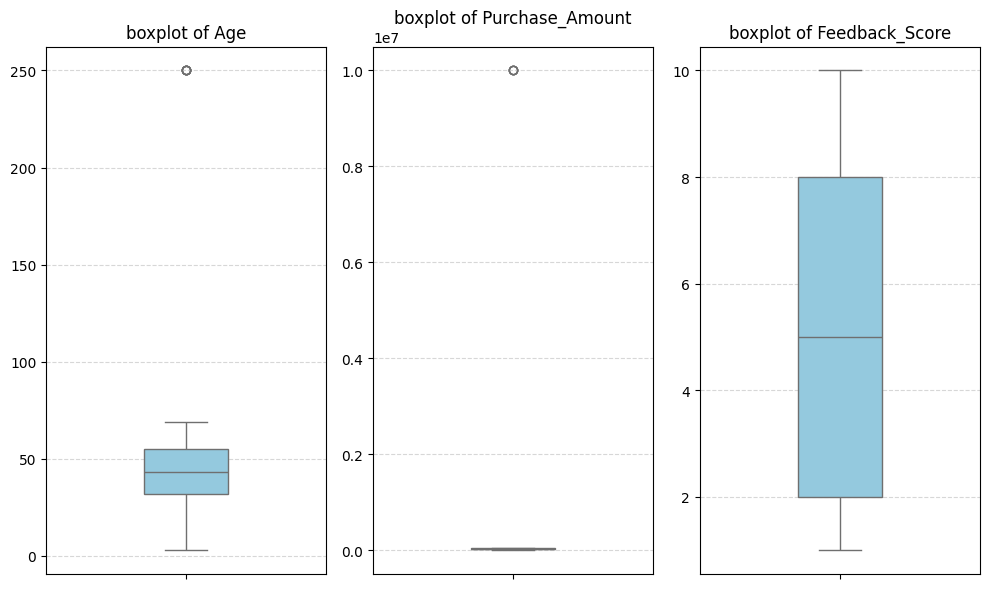

In [57]:
cols = ['Age', 'Purchase_Amount', 'Feedback_Score']
plt.figure(figsize=(10,6))

for i, col in enumerate(cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y = df[col], color = 'skyblue', width = 0.3)
    plt.title(f'boxplot of {col}', fontsize = 12)
    plt.ylabel ("")
    plt.grid(axis='y', linestyle = '--', alpha = 0.5)

plt.tight_layout()
plt.show()

There are outliers except Feedback Score.

In [58]:
from scipy import stats

In [59]:
stats.zscore(df[['Age', 'Purchase_Amount']])

array([[ 0.55651361, -0.01014723],
       [ 0.49058812,  0.07152616],
       [ 1.21576841,  0.0126395 ],
       ...,
       [-0.56421956, -0.02332755],
       [-1.22347436,  0.07000736],
       [ 0.75429005, -0.0486725 ]], shape=(9000, 2))

Convert the negative into positive values.

In [60]:
import numpy as np
zscore = np.abs(stats.zscore(df[['Age', 'Purchase_Amount']]))

Those which has zscore more than 3 is outliers. We can remove them.

In [61]:
df[(zscore>3).any(axis = 1)]

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
470,CUST6977,Tyler Stout,female,250,chennai,2022-05-21,2025-05-31,3554.0,2.0,hudsonsandra@example.net,5752427586,india
932,CUST1207,Cathy Robinson,female,250,delhi,2024-10-24,2025-10-01,23012.0,6.0,jefftaylor@example.org,1244788430,india
2383,CUST3987,Erica Johnson,male,47,kolkata,2020-11-03,2025-08-10,9999999.0,5.0,bflowers@example.com,747807729,india
3368,CUST7314,Gavin Yates,male,50,bangalore,2022-06-30,2025-03-22,9999999.0,10.0,millermichael@example.com,1481715956,india
4674,CUST8481,Denise Combs,female,62,mumbai,2024-10-06,2025-07-08,9999999.0,3.0,cmorales@example.net,2931912910,india
4692,CUST10561,Richard Brown,female,58,mumbai,2024-04-13,2025-09-08,9999999.0,2.0,kevintaylor@example.net,7047881855,india
5279,CUST4536,Alexandra Ramos,male,250,chennai,2021-09-30,2025-03-03,3296.0,10.0,drakemichelle@example.org,5651607326,india
5949,CUST7041,Joseph Young,male,250,delhi,2022-01-20,2024-11-26,1131.0,8.0,pmckenzie@example.org,9456700786,india
6085,CUST8110,Betty Cole,female,250,bangalore,2024-01-07,2025-04-12,25974.0,1.0,dmitchell@example.net,366613689,india
7752,CUST5388,Lauren Smith,male,250,chennai,2024-12-20,2024-10-17,43258.0,6.0,hernandezdonna@example.org,5886842393,india


In [62]:
df_clean = df[~(zscore > 3).any(axis = 1)]
# ~ means negation.
# It keeps only the rows where (zscore > 3).any(axis=1) is False,
# i.e., rows that do not contain any z-score greater than 3.

In [63]:
df_clean

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
0,CUST4371,Paul Wilson,male,52,kolkata,2025-06-26,2025-05-17,26944.0,1.0,peckvictoria@example.com,2131107701,india
1,CUST5957,Jason Thomas,male,51,kolkata,2021-02-17,2025-07-22,44152.0,2.0,owensanthony@example.com,1080761560,india
2,CUST3754,Brittney Martinez,female,62,hyderabad,2023-11-05,2024-12-08,31745.0,2.0,tara39@example.org,8981006345,india
3,CUST2934,Brenda Pierce,female,40,hyderabad,2022-03-13,2025-10-02,39674.0,1.0,berrynancy@example.org,8228064204,india
4,CUST5683,Matthew Carroll,female,41,chennai,2024-04-05,2024-12-15,24268.0,8.0,denise84@example.org,2665569480,india
...,...,...,...,...,...,...,...,...,...,...,...,...
10193,CUST6352,Isaiah Terry,female,26,kolkata,2023-03-04,2025-06-30,43655.0,6.0,lopezleonard@example.net,7694723210,india
10194,CUST6146,Cody Thompson,female,40,kolkata,2024-08-21,2024-10-26,35101.0,1.0,mitchellrivera@example.net,6380823112,india
10195,CUST10767,Robert Lewis,female,35,delhi,2020-12-08,2025-01-25,24167.0,9.0,barrycrane@example.net,5004696571,india
10197,CUST6315,Joshua Martinez,male,25,hyderabad,2022-02-15,2025-01-11,43832.0,2.0,kelli74@example.org,8147428496,india
